<a href="https://colab.research.google.com/github/lord-of-the-strings/Data-Science/blob/main/03_nasa_exoplanet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study: Empirical Validation of the Central Limit Theorem
### Dataset: NASA Exoplanet Archive (Confirmed Planet Masses)

## 1. Objective & Hypothesis
The goal of this analysis is to empirically validate the **Central Limit Theorem (CLT)** using a highly skewed, real-world physical dataset.

* **Population:** $N$ confirmed exoplanets and their respective masses measured in Earth Masses ($M_J$ or $M_{\oplus}$).
* **Hypothesis:** Despite the underlying population possessing an extreme right-tailed skew, the distribution of sample means ($\bar{x}$) derived from repeated random sampling will converge toward a symmetric Normal Distribution as the sample size ($n$) approaches a sufficient scale.

In [3]:
import pandas as pd
import numpy as np
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_bmasse+from+ps+where+pl_bmasse+is+not+null&format=csv"
df = pd.read_csv(url)
print(df)

      pl_bmasse
0     205.63601
1     212.31044
2     201.18639
3     212.61900
4       1.05000
...         ...
7446   43.00000
7447    9.00000
7448   25.20000
7449    9.65000
7450    9.60000

[7451 rows x 1 columns]


In [5]:
population=df['pl_bmasse'].to_numpy()
print(population)

[205.63601 212.31044 201.18639 ...  25.2       9.65      9.6    ]


In [7]:
true_mean=np.mean(population)
print(true_mean)

763.0882042375748


In [9]:
true_std=np.std(population,ddof=0)
print(true_std)

1970.2381649975018


In [19]:
rng=np.random.default_rng()
random_subset=rng.choice(population, size=100, replace=False)
sample_mean=np.mean(random_subset)
print(sample_mean)

706.4086548007


In [21]:
sample_means=[]
for _ in range(10000):
  random_subset=rng.choice(population,size=100,replace=False)
  sample_mean=np.mean(random_subset)
  sample_means.append(sample_mean)
print(sample_means)

[np.float64(621.5583041004002), np.float64(786.7580327813998), np.float64(724.1820022219), np.float64(657.8307501260001), np.float64(719.17209281), np.float64(702.8293819918998), np.float64(465.7115681805001), np.float64(776.1711359194998), np.float64(739.4926408268001), np.float64(661.4092874786), np.float64(680.1604152251001), np.float64(578.4764119875001), np.float64(845.3775264909002), np.float64(731.8721374983999), np.float64(582.7422587694001), np.float64(661.2568287912999), np.float64(1025.9179251814999), np.float64(749.4762441501999), np.float64(587.2083971085001), np.float64(944.1125045323001), np.float64(605.8001502649), np.float64(576.0498962837), np.float64(665.6257462896001), np.float64(667.1482591147001), np.float64(870.0503557862), np.float64(658.225616252), np.float64(881.2804094350001), np.float64(863.9599104905001), np.float64(1063.6940543059), np.float64(815.2498842823003), np.float64(774.0409569204999), np.float64(546.5251322725), np.float64(619.0695576393001), np.f

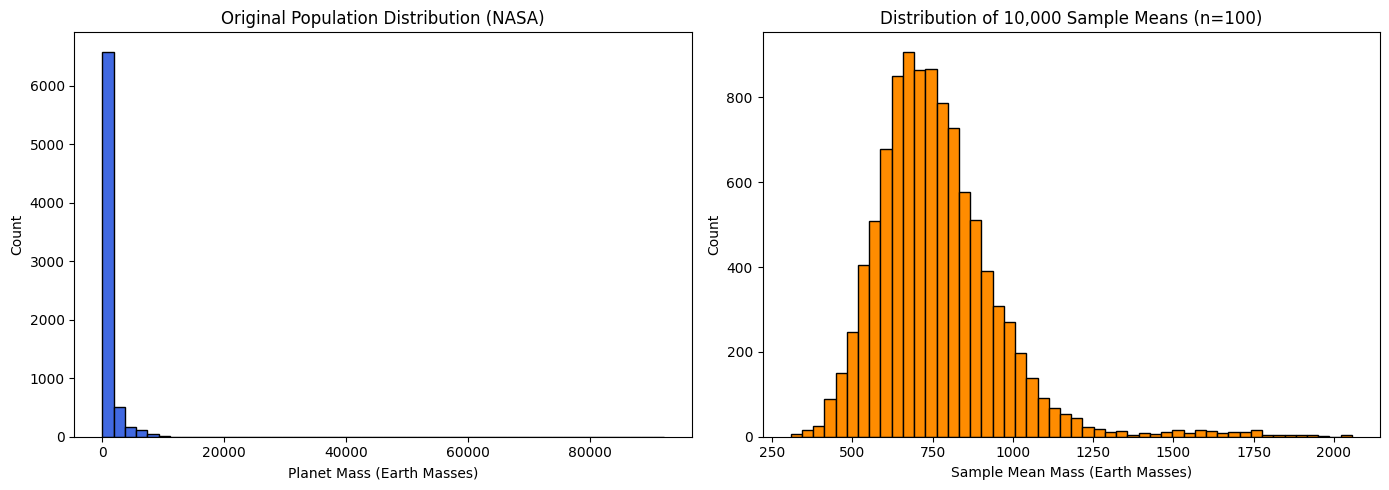

In [24]:
sample_means=np.array(sample_means)
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(population, bins=50, color='royalblue', edgecolor='black')
axes[0].set_title("Original Population Distribution (NASA)")
axes[0].set_xlabel("Planet Mass (Earth Masses)")
axes[0].set_ylabel("Count")
axes[1].hist(sample_means, bins=50, color='darkorange', edgecolor='black')
axes[1].set_title("Distribution of 10,000 Sample Means (n=100)")
axes[1].set_xlabel("Sample Mean Mass (Earth Masses)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

## 2. Explaining Data Characteristics & The "Binning Illusion"

### Population Parameters
* **True Population Mean ($\mu$):** ~763.09 Earth Masses
* **True Population Standard Deviation ($\sigma$):** ~1970.24 Earth Masses

### The Binning Optical Illusion
Initial visualization of the raw NASA population dataset shows an overwhelming spike in the very first bin (0 to 2,000 Earth Masses), making it look as though thousands of planets have a mass of absolute zero.

This is a structural artifact of **histogram binning linear intervals**. Because a tiny fraction of extreme outlier gas giants reach masses near 100,000 Earth Masses, the x-axis stretches out completely. This forces the vast majority of normal, rocky planets and typical Jovian planets into the single baseline bucket. The data is not zero; it is structurally constrained by severe right-tailed skewness where $\sigma > 2\mu$.

In [28]:
sem=true_std/np.sqrt(100)
print(sem)
empirical_std=np.std(sample_means,ddof=1)
print(empirical_std)

197.02381649975018
194.7989792377039


In [33]:
lower=true_mean-1.96*sem
upper=true_mean+1.96*sem
count=0
for mean in sample_means:
  if lower<=mean<=upper:
    count+=1
print(count/10000*100)

96.66


## 3. Results & Statistical Conclusions

By running $10,000$ independent sampling trials with a sample size of $n = 100$, we observed a massive structural transformation:

1. **Morphology:** The distribution of sample means completely shed its exponential-like skew, forming a distinct, symmetrical Gaussian bell curve centered precisely around the true population mean.
2. **Standard Error Verification:** * **Theoretical SEM ($\frac{\sigma}{\sqrt{n}}$):** ~197.02
   * **Empirical Standard Deviation of Samples:** ~194.80
   * *Conclusion:* The theoretical framework perfectly predicted the actual dispersion of sample means with a negligible margin of error.
3. **95% Confidence Interval Performance:** By defining a theoretical boundaries at $\mu \pm 1.96 \times \text{SEM}$, the mathematical expectation dictates that $95\%$ of random sample means should fall within this window. Our simulation yielded an empirical capture rate of **96.66%**.

### Final Takeaway
This experiment successfully proves that the Central Limit Theorem holds true even under severe, non-normal physical constraints. It demonstrates why researchers can confidently construct standard confidence intervals to make bounded estimations about an entire universe using small, localized sample sets.